# Modelo de Classificação - Prever se um produto será vendido

## Problema

Pretende-se prever a variável `sold`:

- `0`: o produto não foi vendido;
- `1`: o produto foi vendido.

O modelo considera o desconto, características do produto e características da loja.

São comparados quatro modelos aprendidos nas aulas: Regressão Logística, Árvore de Decisão, Random Forest e Gradient Boosting. A comparação usa validação cruzada, F1, ROC-AUC e um conjunto de teste final.

## 1. Importar as bibliotecas

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')

pasta_dados = Path('../Dados Clean')
pasta_saida = Path('.')
RANDOM_STATE = 42

## 2. Carregar e juntar os dados

In [ ]:
df_labels = pd.read_excel(
    pasta_dados / 'Data_labels_clean.xlsx'
)

df_store = pd.read_excel(
    pasta_dados / 'Data_store_clean.xlsx'
)

# Uma linha continua a representar uma etiqueta/produto.
dados = df_labels.merge(
    df_store,
    on='idstore',
    how='left'
)

for coluna in ['labelling_date', 'expiring_date', 'sell_date']:
    dados[coluna] = pd.to_datetime(
        dados[coluna],
        errors='coerce'
    )

# Informação conhecida quando o produto é etiquetado.
dados['days_to_expiry'] = (
    dados['expiring_date'] -
    dados['labelling_date']
).dt.days

# Variável conhecida no momento da etiquetagem:
# 1 = sábado ou domingo; 0 = dia útil.
dados['fim_semana_etiqueta'] = (
    dados['labelling_date'].dt.dayofweek >= 5
).astype(int)

print('Etiquetas:', len(dados))
print('Lojas:', dados['idstore'].nunique())
print('SKU:', dados['sku'].nunique())
display(dados.head())

Etiquetas: 150023
Lojas: 332
SKU: 318


,idstore,sku,brand,weight (g),oldpvp,new_pvp,discount,Margin (%),Profit (€),Payment_method,...,expiring_date,perc_expiring_sku,sell_date,sold,type,selling_square_ft,district,area_missing_flag,days_to_expiry,fim_semana_etiqueta
0,1,1,Marca 1,260.0,4.22,2.11,0.5,16,0.3376,Card,...,2021-10-03,0.010050,2021-10-02,1,Large,4762.0,Évora,0,2,0
1,1,1,Marca 1,260.0,3.96,1.98,0.5,16,0.3168,NaN,...,2021-10-02,0.005025,NaT,0,Large,4762.0,Évora,0,1,0
2,1,1,Marca 1,260.0,4.74,2.37,0.5,16,0.3792,Cash,...,2021-10-03,0.010050,2021-10-03,1,Large,4762.0,Évora,0,2,0
3,1,1,Marca 1,260.0,4.20,2.10,0.5,16,0.3360,Card,...,2021-10-03,0.010050,2021-10-02,1,Large,4762.0,Évora,0,2,0
4,1,1,Marca 1,260.0,4.62,2.31,0.5,16,0.3696,Cash,...,2021-10-03,0.010050,2021-10-03,1,Large,4762.0,Évora,0,2,0


O `Data_labels_clean` é a base porque o target existe ao nível de cada etiqueta. O `Data_store_clean` acrescenta `type`, `selling_square_ft` e `district`. Na versão atual dos dados clean, foram preenchidos os 31 valores em falta de `selling_square_ft` e foi criada `area_missing_flag`. Para manter a mesma metodologia e comparar os resultados de forma justa, a nova flag não foi adicionada às variáveis do modelo. Não se usa `lojas_segmentadas_FINAL`, porque os segmentos foram calculados a partir das próprias vendas e poderiam provocar data leakage.

## 3. Explorar a variável que queremos prever

,sold,numero_etiquetas,percentagem
0,0,69541,46.35
1,1,80482,53.65


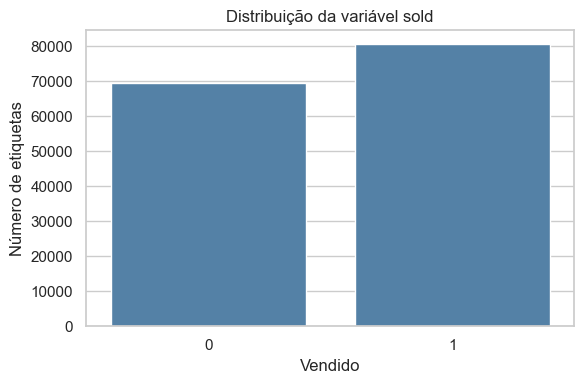

In [3]:
distribuicao_target = (
    dados['sold']
    .value_counts()
    .sort_index()
    .rename_axis('sold')
    .reset_index(name='numero_etiquetas')
)

distribuicao_target['percentagem'] = (
    distribuicao_target['numero_etiquetas']
    / len(dados) * 100
)

display(distribuicao_target.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=dados, x='sold', color='steelblue')
plt.title('Distribuição da variável sold')
plt.xlabel('Vendido')
plt.ylabel('Número de etiquetas')
plt.tight_layout()
plt.show()

As duas classes têm dimensões próximas. Por isso, não é necessário aplicar técnicas de balanceamento antes de testar os primeiros modelos.

## 4. Escolher as variáveis

In [4]:
variaveis_numericas = [
    'discount',
    'new_pvp',
    'weight (g)',
    'Margin (%)',
    'Profit (€)',
    'sku_shelf_life',
    'perc_expiring_sku',
    'days_to_expiry',
    'fim_semana_etiqueta',
    'selling_square_ft'
]

variaveis_categoricas = [
    'brand',
    'type',
    'district'
]

features = variaveis_numericas + variaveis_categoricas

X = dados[features].copy()
y = dados['sold'].astype(int)

print('Variáveis numéricas:', variaveis_numericas)
print('Variáveis categóricas:', variaveis_categoricas)
print('Target: sold')

Variáveis numéricas: ['discount', 'new_pvp', 'weight (g)', 'Margin (%)', 'Profit (€)', 'sku_shelf_life', 'perc_expiring_sku', 'days_to_expiry', 'fim_semana_etiqueta', 'selling_square_ft']
Variáveis categóricas: ['brand', 'type', 'district']
Target: sold


### Variáveis excluídas

- `sell_date` e `Payment_method`: só existem depois da venda e revelam diretamente o target;
- `sold`: é a variável que queremos prever;
- `idstore`: é apenas um identificador; usamos as características da loja;
- `sku`: identifica um produto específico e poderia levar o modelo a memorizar produtos;
- `oldpvp`: foi excluído porque está diretamente relacionado com `new_pvp` e `discount`;
- clusters e segmentos de loja: foram construídos com resultados de venda do mesmo período.

Todas as variáveis mantidas são conhecidas quando o produto é etiquetado.

A variável `fim_semana_etiqueta` foi criada a partir de `labelling_date`: vale 1 ao sábado/domingo e 0 nos dias úteis. Pode ser usada porque é conhecida antes da venda. Não foi criada qualquer variável a partir de `sell_date`, pois isso provocaria fuga de informação.


## 5. Separar treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Treino:', len(X_train))
print('Teste:', len(X_test))
print('Taxa de venda no treino:', round(y_train.mean(), 3))
print('Taxa de venda no teste:', round(y_test.mean(), 3))

Treino: 120018
Teste: 30005
Taxa de venda no treino: 0.536
Taxa de venda no teste: 0.536


O modelo aprende com 80% das observações e é avaliado nos 20% que não viu durante o treino. `stratify=y` mantém aproximadamente a mesma proporção de vendidos e não vendidos nos dois conjuntos.

## 6. Preparar variáveis numéricas e categóricas

In [6]:
preprocessamento = ColumnTransformer(
    transformers=[
        (
            'numericas',
            Pipeline(steps=[
                (
                    'preencher_nulos',
                    SimpleImputer(strategy='median')
                ),
                (
                    'normalizar',
                    StandardScaler()
                )
            ]),
            variaveis_numericas
        ),
        (
            'categoricas',
            Pipeline(steps=[
                (
                    'preencher_nulos',
                    SimpleImputer(strategy='most_frequent')
                ),
                (
                    'one_hot',
                    OneHotEncoder(handle_unknown='ignore')
                )
            ]),
            variaveis_categoricas
        )
    ]
)

A mediana preenche valores numéricos em falta. Nas categorias usa-se o valor mais frequente. O `StandardScaler` normaliza números e o `OneHotEncoder` transforma categorias em colunas 0/1. A `Pipeline` garante que estas operações são aprendidas apenas com o treino.

## 7. Modelo 1 — Regressão Logística

In [7]:
modelo_logistico = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    (
        'modelo',
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

print('Regressão Logística preparada.')

Regressão Logística preparada.


A Regressão Logística é usada como modelo base. É simples e ajuda a perceber se relações lineares já são suficientes para separar vendidos e não vendidos.

## 8. Modelo 2 — Árvore de Decisão

In [8]:
modelo_arvore = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    (
        'modelo',
        DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=25,
            random_state=RANDOM_STATE
        )
    )
])

print('Árvore de Decisão preparada.')

Árvore de Decisão preparada.


A Árvore de Decisão cria regras sucessivas para separar os produtos. Foi acrescentada por ser um modelo aprendido nas aulas e por fornecer uma comparação simples com os modelos que combinam várias árvores.

## 9. Modelo 3 — Random Forest e teste de parâmetros

In [9]:
random_forest_base = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    (
        'modelo',
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1
        )
    )
])

# Foram testadas quatro combinações simples.
parametros_rf = [
    {
        'modelo__n_estimators': [100],
        'modelo__max_depth': [10],
        'modelo__min_samples_leaf': [10]
    },
    {
        'modelo__n_estimators': [100],
        'modelo__max_depth': [14],
        'modelo__min_samples_leaf': [10]
    },
    {
        'modelo__n_estimators': [200],
        'modelo__max_depth': [14],
        'modelo__min_samples_leaf': [5]
    },
    {
        'modelo__n_estimators': [200],
        'modelo__max_depth': [20],
        'modelo__min_samples_leaf': [5]
    }
]

cv_parametros = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

busca_rf = GridSearchCV(
    estimator=random_forest_base,
    param_grid=parametros_rf,
    scoring='f1',
    cv=cv_parametros,
    n_jobs=1,
    return_train_score=True
)

busca_rf.fit(X_train, y_train)

modelo_random_forest = busca_rf.best_estimator_

resultados_parametros_rf = pd.DataFrame(
    busca_rf.cv_results_
)[
    [
        'params',
        'mean_train_score',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]
].sort_values('rank_test_score')

print('Melhores parâmetros da Random Forest:')
print(busca_rf.best_params_)
print('Melhor F1 médio:', round(busca_rf.best_score_, 4))
display(resultados_parametros_rf.round(4))

Melhores parâmetros da Random Forest:
{'modelo__max_depth': 20, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 200}
Melhor F1 médio: 0.7235


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,"{'modelo__max_depth': 20, 'modelo__min_samples...",0.7512,0.7235,0.0019,1
2,"{'modelo__max_depth': 14, 'modelo__min_samples...",0.7306,0.7159,0.0016,2
1,"{'modelo__max_depth': 14, 'modelo__min_samples...",0.7238,0.7121,0.0022,3
0,"{'modelo__max_depth': 10, 'modelo__min_samples...",0.7148,0.7086,0.0035,4


O Random Forest combina várias árvores de decisão e utiliza o resultado conjunto para obter previsões mais estáveis e reduzir o risco de sobreajuste de uma única árvore.

Os parâmetros foram escolhidos apenas com os dados de treino. O `GridSearchCV` compara as combinações através de validação cruzada e seleciona a que apresenta o maior F1 médio.

## 10. Modelo 4 — Gradient Boosting

In [10]:
modelo_gradient_boosting = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    (
        'modelo',
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    )
])

print('Gradient Boosting preparado.')

Gradient Boosting preparado.


O Gradient Boosting cria árvores sequencialmente. Cada nova árvore tenta corrigir os erros das anteriores. Foram mantidos os parâmetros base usados no projeto final das aulas.

## 11. Aplicar validação cruzada aos quatro modelos

In [11]:
modelos = {
    'Regressão Logística': modelo_logistico,
    'Árvore de Decisão': modelo_arvore,
    'Random Forest': modelo_random_forest,
    'Gradient Boosting': modelo_gradient_boosting
}

validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_cv = []

for nome, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=validacao_cruzada,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ],
        return_train_score=True,
        n_jobs=1
    )

    resultados_cv.append({
        'modelo': nome,
        'cv_accuracy_media': scores['test_accuracy'].mean(),
        'cv_precision_media': scores['test_precision'].mean(),
        'cv_recall_media': scores['test_recall'].mean(),
        'cv_f1_media': scores['test_f1'].mean(),
        'cv_f1_desvio': scores['test_f1'].std(),
        'cv_roc_auc_media': scores['test_roc_auc'].mean(),
        'treino_f1_media': scores['train_f1'].mean(),
        'diferenca_treino_cv': (
            scores['train_f1'].mean() -
            scores['test_f1'].mean()
        )
    })

resultados_validacao = pd.DataFrame(
    resultados_cv
).sort_values(
    'cv_f1_media',
    ascending=False
).reset_index(drop=True)

display(resultados_validacao.round(4))

,modelo,cv_accuracy_media,cv_precision_media,cv_recall_media,cv_f1_media,cv_f1_desvio,cv_roc_auc_media,treino_f1_media,diferenca_treino_cv
0,Random Forest,0.6909,0.6932,0.7605,0.7253,0.0018,0.7585,0.7513,0.0260
1,Gradient Boosting,0.6625,0.6648,0.7478,0.7039,0.0028,0.7147,0.7060,0.0021
2,Regressão Logística,0.6342,0.6224,0.8090,0.7035,0.0017,0.6618,0.7041,0.0005
3,Árvore de Decisão,0.6550,0.6673,0.7121,0.6889,0.0042,0.6952,0.6907,0.0018


O F1 médio mostra o desempenho nas cinco divisões. O desvio-padrão mostra a estabilidade. A diferença entre o F1 de treino e o F1 de validação ajuda a identificar possível sobreajuste.

## 12. Treinar e comparar os modelos no teste final

In [12]:
previsoes_modelos = {}
probabilidades_modelos = {}
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    previsoes_modelos[nome] = modelo.predict(X_test)
    probabilidades_modelos[nome] = (
        modelo.predict_proba(X_test)[:, 1]
    )
    modelos_treinados[nome] = modelo

resultados_teste = []

for nome in modelos:
    previsao = previsoes_modelos[nome]
    probabilidade = probabilidades_modelos[nome]

    resultados_teste.append({
        'modelo': nome,
        'accuracy_teste': accuracy_score(
            y_test,
            previsao
        ),
        'precision_teste': precision_score(
            y_test,
            previsao
        ),
        'recall_teste': recall_score(
            y_test,
            previsao
        ),
        'f1_teste': f1_score(
            y_test,
            previsao
        ),
        'roc_auc_teste': roc_auc_score(
            y_test,
            probabilidade
        )
    })

resultados_teste = pd.DataFrame(resultados_teste)

resultados_modelos = resultados_validacao.merge(
    resultados_teste,
    on='modelo',
    how='left'
).sort_values(
    'cv_f1_media',
    ascending=False
).reset_index(drop=True)

display(resultados_modelos.round(4))

,modelo,cv_accuracy_media,cv_precision_media,cv_recall_media,cv_f1_media,cv_f1_desvio,cv_roc_auc_media,treino_f1_media,diferenca_treino_cv,accuracy_teste,precision_teste,recall_teste,f1_teste,roc_auc_teste
0,Random Forest,0.6909,0.6932,0.7605,0.7253,0.0018,0.7585,0.7513,0.0260,0.6944,0.6975,0.7596,0.7273,0.7630
1,Gradient Boosting,0.6625,0.6648,0.7478,0.7039,0.0028,0.7147,0.7060,0.0021,0.6623,0.6646,0.7481,0.7039,0.7142
2,Regressão Logística,0.6342,0.6224,0.8090,0.7035,0.0017,0.6618,0.7041,0.0005,0.6351,0.6235,0.8070,0.7035,0.6649
3,Árvore de Decisão,0.6550,0.6673,0.7121,0.6889,0.0042,0.6952,0.6907,0.0018,0.6575,0.6699,0.7127,0.6906,0.6944


O modelo final é escolhido pelo maior F1 médio da validação cruzada. As métricas do teste são usadas apenas para confirmar o desempenho em observações que não participaram no treino nem na escolha dos parâmetros.

## 13. Curvas ROC e AUC

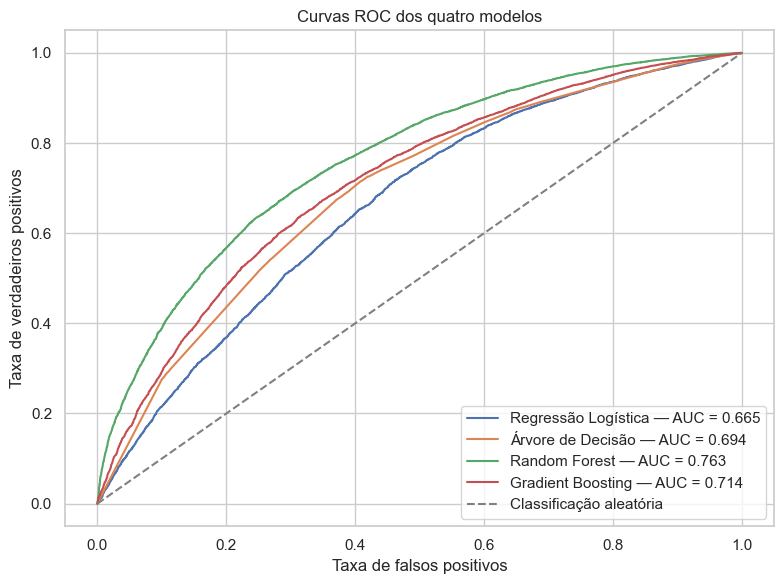

In [13]:
plt.figure(figsize=(8, 6))

for nome, probabilidade in probabilidades_modelos.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilidade
    )

    auc = roc_auc_score(
        y_test,
        probabilidade
    )

    plt.plot(
        fpr,
        tpr,
        label=nome + ' — AUC = ' + str(round(auc, 3))
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='grey',
    label='Classificação aleatória'
)

plt.title('Curvas ROC dos quatro modelos')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()
plt.tight_layout()
plt.show()

O ROC-AUC avalia a capacidade geral de separar vendidos de não vendidos considerando todos os possíveis limites de decisão. É uma métrica complementar: o F1 continua a ser o critério principal.

## 14. Escolher e avaliar o melhor modelo

Melhor modelo pela validação cruzada: Random Forest



,precision,recall,f1-score,support
Não vendido,0.69,0.62,0.65,13908.0
Vendido,0.70,0.76,0.73,16097.0


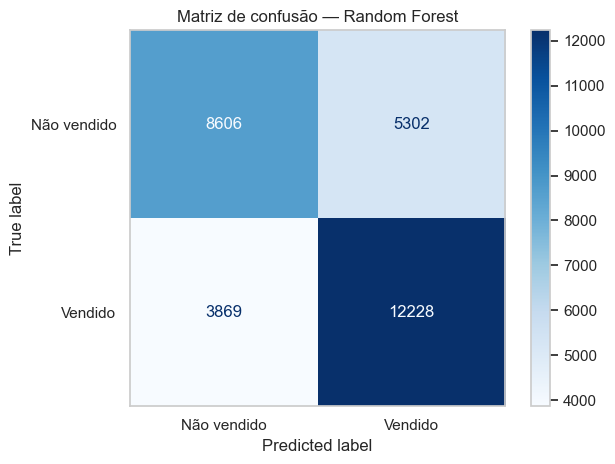

In [14]:
melhor_nome = resultados_modelos.loc[0, 'modelo']
melhor_modelo = modelos_treinados[melhor_nome]
melhor_previsao = previsoes_modelos[melhor_nome]
melhor_probabilidade = probabilidades_modelos[melhor_nome]

print('Melhor modelo pela validação cruzada:', melhor_nome)
print()

relatorio = classification_report(
    y_test,
    melhor_previsao,
    target_names=['Não vendido', 'Vendido'],
    output_dict=True
)

relatorio = pd.DataFrame(relatorio).T

# Mostrar apenas as duas classes.
relatorio = relatorio.loc[
    ['Não vendido', 'Vendido']
]

display(relatorio.round(2))

matriz = confusion_matrix(
    y_test,
    melhor_previsao
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Não vendido', 'Vendido']
).plot(cmap='Blues')

plt.title('Matriz de confusão — ' + melhor_nome)
plt.grid(False)
plt.tight_layout()
plt.show()

A matriz de confusão apresenta:

- verdadeiros negativos: não vendidos corretamente identificados;
- falsos positivos: previstos como vendidos, mas não vendidos;
- falsos negativos: vendidos que o modelo não identificou;
- verdadeiros positivos: vendidos corretamente identificados.

## 15. Encontrar as variáveis mais preditivas

In [15]:
# Usar uma amostra do teste para tornar o cálculo mais rápido.
amostra = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=RANDOM_STATE
)
y_amostra = y_test.loc[amostra.index]

resultado_importancia = permutation_importance(
    melhor_modelo,
    amostra,
    y_amostra,
    scoring='f1',
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importancia_variaveis = pd.DataFrame({
    'variavel': amostra.columns,
    'importancia': resultado_importancia.importances_mean,
    'desvio': resultado_importancia.importances_std
}).sort_values(
    'importancia',
    ascending=False
).reset_index(drop=True)

display(importancia_variaveis.round(4))

,variavel,importancia,desvio
0,brand,0.0881,0.0038
1,district,0.0173,0.0011
2,weight (g),0.0121,0.0011
3,selling_square_ft,0.0112,0.0019
4,perc_expiring_sku,0.0110,0.0018
5,type,0.0092,0.0025
6,days_to_expiry,0.0071,0.0018
7,new_pvp,0.0051,0.0001
8,Profit (€),0.0042,0.0018
9,Margin (%),0.0040,0.0006


A `permutation_importance` baralha uma variável de cada vez e mede quanto o F1 piora. Quanto maior a redução, mais útil era essa variável. Valores próximos de zero, incluindo pequenos valores negativos, indicam que a contribuição não foi estável nesta amostra. Importância preditiva não significa causalidade.

## 16. Analisar especificamente o desconto

,discount,numero_etiquetas,taxa_venda
16,0.30,130649,0.539
17,0.31,8693,0.523
13,0.25,4355,0.488
23,0.51,2315,0.543
22,0.50,1326,0.588
10,0.20,1158,0.522
14,0.26,609,0.562
6,0.15,455,0.473
4,0.10,298,0.547
7,0.16,64,0.594


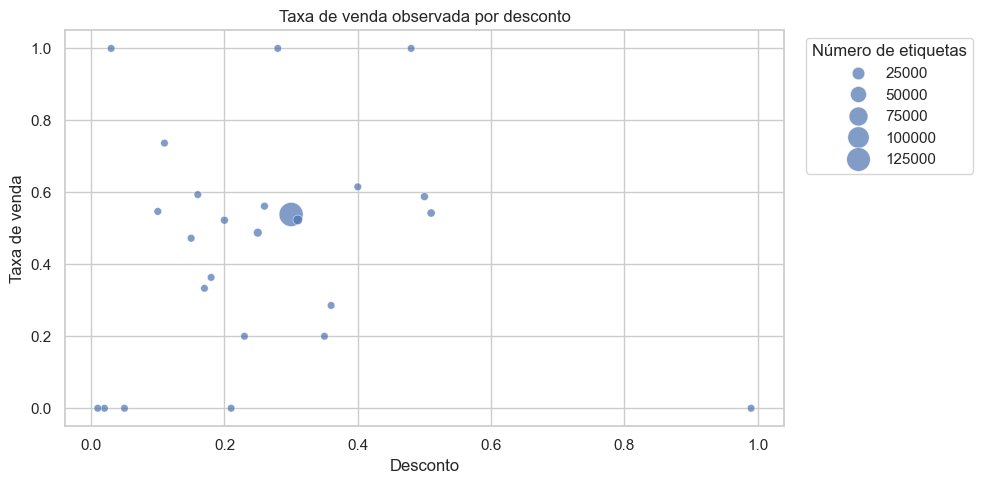

In [16]:
analise_desconto = (
    dados.groupby('discount')
    .agg(
        numero_etiquetas=('sold', 'size'),
        taxa_venda=('sold', 'mean')
    )
    .reset_index()
    .sort_values(
        'numero_etiquetas',
        ascending=False
    )
)

display(analise_desconto.head(15).round(3))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=analise_desconto,
    x='discount',
    y='taxa_venda',
    size='numero_etiquetas',
    sizes=(30, 300),
    alpha=0.7
)
plt.title('Taxa de venda observada por desconto')
plt.xlabel('Desconto')
plt.ylabel('Taxa de venda')

plt.legend(
    title='Número de etiquetas',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

O gráfico descreve uma associação observada. O tamanho das bolas representa o número de produtos. Resultados baseados em poucos casos devem ser interpretados com cuidado. Não se pode afirmar que aumentar o desconto causa, por si só, um aumento da venda.

## 17. Guardar os resultados

In [17]:
relatorio_classificacao = pd.DataFrame(
    classification_report(
        y_test,
        melhor_previsao,
        target_names=['Não vendido', 'Vendido'],
        output_dict=True
    )
).T.reset_index(names='classe')

matriz_exportar = pd.DataFrame(
    matriz,
    index=['Real_não_vendido', 'Real_vendido'],
    columns=['Previsto_não_vendido', 'Previsto_vendido']
).reset_index(names='classe_real')

previsoes_teste = dados.loc[
    X_test.index,
    [
        'idstore',
        'brand',
        'discount',
        'new_pvp',
        'sold'
    ]
].copy()

previsoes_teste['probabilidade_venda'] = (
    melhor_probabilidade
)
previsoes_teste['previsao'] = melhor_previsao
previsoes_teste['previsao_correta'] = (
    previsoes_teste['sold'] ==
    previsoes_teste['previsao']
).astype(int)

resumo_dados = pd.DataFrame({
    'indicador': [
        'Número de etiquetas',
        'Número de lojas',
        'Percentagem vendida',
        'Observações de treino',
        'Observações de teste',
        'Melhor modelo',
        'Critério de seleção',
        'F1 médio da validação',
        'F1 do teste',
        'ROC-AUC do teste'
    ],
    'valor': [
        len(dados),
        dados['idstore'].nunique(),
        dados['sold'].mean() * 100,
        len(X_train),
        len(X_test),
        melhor_nome,
        'Maior F1 médio na validação cruzada',
        resultados_modelos.loc[0, 'cv_f1_media'],
        resultados_modelos.loc[0, 'f1_teste'],
        resultados_modelos.loc[0, 'roc_auc_teste']
    ]
})

with pd.ExcelWriter(
    pasta_saida /
    'results_product_sales_prediction_model.xlsx'
) as writer:
    resumo_dados.to_excel(
        writer,
        sheet_name='Resumo',
        index=False
    )
    resultados_modelos.to_excel(
        writer,
        sheet_name='Comparacao_Modelos',
        index=False
    )
    resultados_parametros_rf.to_excel(
        writer,
        sheet_name='Parametros_Random_Forest',
        index=False
    )
    relatorio_classificacao.to_excel(
        writer,
        sheet_name='Relatorio_Classificacao',
        index=False
    )
    matriz_exportar.to_excel(
        writer,
        sheet_name='Matriz_Confusao',
        index=False
    )
    importancia_variaveis.to_excel(
        writer,
        sheet_name='Importancia_Variaveis',
        index=False
    )
    analise_desconto.to_excel(
        writer,
        sheet_name='Analise_Desconto',
        index=False
    )
    previsoes_teste.to_excel(
        writer,
        sheet_name='Previsoes_Teste',
        index=False
    )

artefacto = {
    'modelo': melhor_modelo,
    'features': features,
    'target': 'sold',
    'melhor_modelo': melhor_nome,
    'criterio_selecao': 'cv_f1_media',
    'melhores_parametros_rf': busca_rf.best_params_
}

joblib.dump(
    artefacto,
    pasta_saida /
    'product_sales_prediction_model.joblib'
)

print('Resultados e modelo guardados.')

Resultados e modelo guardados.


## 18. Conclusão

Foram comparados quatro modelos. A escolha foi feita pelo **F1 médio da validação cruzada**, e não pelo resultado do teste.

| Modelo | F1 médio CV | Desvio F1 | ROC-AUC médio CV | F1 teste | ROC-AUC teste |
|---|---:|---:|---:|---:|---:|
| Random Forest | **0,7254** | **0,0021** | **0,7586** | **0,7282** | **0,7630** |
| Gradient Boosting | 0,7041 | 0,0027 | 0,7147 | 0,7033 | 0,7145 |
| Regressão Logística | 0,7032 | 0,0019 | 0,6617 | 0,7037 | 0,6651 |
| Árvore de Decisão | 0,6889 | 0,0042 | 0,6951 | 0,6906 | 0,6944 |

O **Random Forest** foi selecionado porque apresentou o maior F1 médio e o maior ROC-AUC médio na validação cruzada. O resultado também se confirmou no teste final:

- Accuracy: 0,6953;
- Precision: 0,6982;
- Recall: 0,7608;
- F1: 0,7282;
- ROC-AUC: 0,7630.

### Parâmetros selecionados

O `GridSearchCV` testou quatro configurações apenas com os dados de treino. A melhor configuração continuou a ser:

- `n_estimators=200`;
- `max_depth=20`;
- `min_samples_leaf=5`.

Esta configuração obteve F1 médio de 0,7232 na pesquisa de três folds. Na comparação final de cinco folds, o F1 médio foi 0,7254.

### Estabilidade e possível sobreajuste

O desvio-padrão do F1 do Random Forest foi 0,0021, mostrando resultados semelhantes nas cinco divisões. O F1 médio de treino foi 0,7516 e o F1 médio de validação foi 0,7254. A diferença de 0,0262 é superior à dos restantes modelos e deve ser acompanhada. Contudo, o F1 do teste foi 0,7282, próximo do resultado da validação, não se observando uma quebra acentuada no teste.

### Matriz de confusão

No conjunto de teste do Random Forest:

- 8 615 produtos não vendidos foram corretamente identificados;
- 5 293 foram previstos como vendidos, mas não venderam;
- 3 850 produtos vendidos não foram identificados;
- 12 247 produtos vendidos foram corretamente identificados.

A Regressão Logística apresentou o maior Recall, mas com Precision, F1 e ROC-AUC inferiores. Isto significa que encontrou uma percentagem maior das vendas reais, mas também classificou mais produtos não vendidos como vendidos.

### Contributo de `fim_semana_etiqueta`

Foi criada a variável `fim_semana_etiqueta` a partir de `labelling_date`:

- `0`: produto etiquetado num dia útil;
- `1`: produto etiquetado ao sábado ou domingo.

A variável é válida para o modelo porque é conhecida no momento da etiquetagem. Não foi utilizado o dia de `sell_date`, pois essa informação só existe depois da venda.

Com a nova variável:

- o F1 médio da validação passou de 0,7245 para 0,7254;
- o F1 do teste passou de 0,7261 para 0,7282;
- o ROC-AUC do teste passou de 0,7605 para 0,7630.

A importância por permutação de `fim_semana_etiqueta` foi 0,0035. O contributo é positivo, mas pequeno. A variável foi mantida por ser simples, conhecida antecipadamente e por apresentar uma melhoria consistente, sem ser tratada como um fator determinante da venda.

### Variáveis mais preditivas

As variáveis com maior importância por permutação foram:

1. `brand`;
2. `district`;
3. `selling_square_ft`;
4. `weight (g)`;
5. `perc_expiring_sku`;
6. `type`.

O `discount` foi mantido porque faz parte explícita do problema. A sua importância ficou próxima de zero nesta amostra. Isto não significa que o desconto não tenha valor comercial nem permite concluir causalidade; significa apenas que acrescentou pouca capacidade preditiva depois das restantes características.

### Decisão final

O Random Forest é o modelo final porque:

- venceu na validação cruzada, evitando escolher o modelo apenas pelo teste;
- apresentou o maior F1 e ROC-AUC;
- mostrou resultados estáveis entre as cinco divisões;
- melhorou depois do teste de parâmetros;
- permite explicar a importância das variáveis.

### Limitações

- A divisão é aleatória e deve ser validada com novos períodos quando existirem.
- A importância das variáveis representa capacidade preditiva, não causalidade.
- O dataset não tem identificador de cliente; permite contar etiquetas e vendas registadas, mas não clientes únicos.
- O modelo deve ser reavaliado se mudarem preços, descontos, produtos ou comportamento dos clientes.
- A pesquisa de parâmetros foi limitada a quatro combinações para manter o código e o tempo de execução adequados ao projeto.

### Redes neuronais

Não foi usada uma rede neuronal nesta versão. Primeiro foram aplicadas as melhorias aprendidas nas aulas: Árvore de Decisão, ROC-AUC, validação cruzada e pesquisa de parâmetros. Uma rede neuronal pode ser testada separadamente como experiência futura e comparada com o F1 e o ROC-AUC do Random Forest.